In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Muon

Every optimizer so far has treated the parameters as one long vector. SGD
moves that vector against the gradient; Adam rescales each entry; AdamW
shrinks them all uniformly. Yet the census of that section showed
that a network is not a homogeneous vector: it is a collection of embedding
tables, hidden *matrices*, and normalization vectors, with most of the
parameters in the matrices. This section takes that structure seriously, and
the reward is the first credible challenger to the Adam family's decade-long
hold on large-scale training.

The organizing idea of this chapter says an optimizer begins with a choice of
descent direction, and this section makes the choice explicit: the direction
of steepest descent *depends on the norm* used to measure the step. Under the
Euclidean norm the answer is the gradient, and we recover the direction of
SGD. Under the
$\ell_\infty$ norm the answer is the sign of the gradient, and we recover, in
essence, Adam. Under the *spectral* norm, the natural way to measure a matrix,
the answer is the gradient with its singular values erased, and we arrive at
Muon [@Jordan.Jin.Boza.ea.2024], which since 2024 has gone from a
speed-run leaderboard to trillion-parameter training runs. We derive it, build
it in about fifteen lines, race it against AdamW on the testbeds of
that section, place it in the family of preconditioned methods it
belongs to, and finish by weighing the evidence.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import math
import torch
from torch import nn

## The Norm Decides the Direction

### Steepest Descent Under a Ball

What does it mean for a direction to be "steepest"? Linearize the loss around
the current iterate, $f(\mathbf{x} + \mathbf{d}) \approx f(\mathbf{x}) +
\langle \mathbf{g}, \mathbf{d} \rangle$, and ask for the step that decreases
it most among all steps of a given size:

$$
\mathbf{d}^\star = \operatorname*{argmin}_{\|\mathbf{d}\| \leq \eta} \; \langle \mathbf{g}, \mathbf{d} \rangle.
$$

The problem is not fully posed until we say which norm defines the ball
$\|\mathbf{d}\| \leq \eta$, and different norms give genuinely different
answers [@Bernstein.Newhouse.2024]. Under the Euclidean norm the ball is
round, the minimizer points straight along $-\mathbf{g}$, and
the equation returns *normalized* gradient descent,
$-\eta\,\mathbf{g}/\|\mathbf{g}\|_2$ — the SGD direction. Ordinary SGD takes
that direction with a length that scales with $\|\mathbf{g}\|_2$
(equivalently, it solves the regularized model $\min_{\mathbf{d}} \langle
\mathbf{g}, \mathbf{d} \rangle + \|\mathbf{d}\|_2^2 / (2\eta)$ rather than the
fixed ball); every ball in this section settles the *direction*, and how the
step length scales is a separate dial. So "just follow the gradient"
was never norm-free; it is the Euclidean choice, made silently, and every
method in this chapter that we described as a modification of SGD can instead
be read as a different answer to the same question.

Take the $\ell_\infty$ norm, $\|\mathbf{d}\|_\infty = \max_i |d_i|$. The ball
is now a box: a step is "size $\eta$" as long as *no single coordinate* moves
more than $\eta$. To make $\langle \mathbf{g}, \mathbf{d} \rangle$ as negative
as possible we push every coordinate to its wall, and the minimizer is
$\mathbf{d}^\star = -\eta\, \mathrm{sign}(\mathbf{g})$: sign descent. This is
not a new acquaintance. In that section we switched off Adam's two
averages ($\beta_1 = \beta_2 = 0$, $\epsilon \to 0$) and were left with
exactly $\eta\,\mathrm{sign}(\mathbf{g}_t)$, and we saw that Adam's advantage
over SGD on language models tracks the advantage of sign descent
[@Kunstner.Chen.Lavington.ea.2023]. In the geometric reading, Adam is
smoothed steepest descent under $\ell_\infty$: the box says "move every
coordinate the same distance, however lopsided the gradient", which is
precisely the per-coordinate equalization that that section found to be
Adam's real work, and the moment estimates are there to keep the sign stable
under minibatch noise. Choosing this ball is sensible exactly when
coordinates have wildly different gradient scales, which is what the
heterogeneity of language models produces.

### Matrices and the Spectral Norm

Both balls above treat the parameter as a bag of coordinates. But the census
told us where the parameters actually live: in our tiny transformer, about
95% sit in two-dimensional hidden matrices whose job is to *transform
activations*, $\mathbf{y} = \mathbf{W}\mathbf{x}$. For such a parameter, what
we should mean by "a step of size $\eta$" is not how much the entries change
but how much the layer's *behavior* changes, and that is governed by the
spectral norm: $\|\Delta \mathbf{W} \mathbf{x}\|_2 \leq \|\Delta
\mathbf{W}\|_2\, \|\mathbf{x}\|_2$, with equality for the worst-case input.
The spectral norm $\|\Delta \mathbf{W}\|_2$, the largest singular value, is
the largest factor by which the update can stretch any activation vector
passing through the layer. Flattening the matrix and using the Euclidean norm
of the entries (the Frobenius norm) instead adds up energy across all
$\min(m, n)$ singular directions, so it can call an update "large" even when
its effect on every activation is small; controlling the spectral norm of
updates is also exactly the condition under which feature learning survives
scaling the network up [@Yang.Simon.Bernstein.2023], a thread
that section picks up.

So let the ball be spectral and solve the equation for a matrix
parameter with gradient $\mathbf{G}$. Write the reduced singular value
decomposition $\mathbf{G} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\top$.
The steepest step is the *orthogonalized gradient*:

$$
\Delta \mathbf{W}^\star = \operatorname*{argmin}_{\|\Delta \mathbf{W}\|_2 \leq \eta} \; \langle \mathbf{G}, \Delta \mathbf{W} \rangle = -\eta\, \mathbf{U} \mathbf{V}^\top.
$$

The argument is one line of duality. For any $\mathbf{A}$ with
$\|\mathbf{A}\|_2 \leq 1$ we have $\langle \mathbf{G}, \mathbf{A} \rangle =
\mathrm{tr}(\boldsymbol{\Sigma}\, \mathbf{U}^\top \mathbf{A} \mathbf{V}) =
\sum_i \sigma_i\, (\mathbf{U}^\top \mathbf{A} \mathbf{V})_{ii} \leq \sum_i
\sigma_i$, since no entry of a matrix with unit spectral norm exceeds one;
choosing $\mathbf{A} = \mathbf{U}\mathbf{V}^\top$ attains the bound, and
negating it attains the minimum. (Checking the diagonal-entry claim is an
exercise; the surrounding theory, including what this has to do with
preconditioning, lives in that section.)

Look at what the equation does. The gradient
$\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ names a set of directions and
weights them by singular values that, for real training gradients, are
dominated by a few large ones. The steepest spectral step keeps the
directions and *erases the weights*: every direction the gradient identifies
moves at the same rate. This is per-direction equalization, in whatever basis
the gradient supplies, where Adam manages only per-coordinate equalization in
the axis basis it is handed. The reasoning also says where it does *not*
apply. An embedding table never multiplies a dense activation vector; its
input is one-hot, each row is looked up in isolation, and the norm the input
induces is the largest *row* norm rather than the spectral norm — a geometry
for which spectral orthogonalization is the wrong tool
[@Bernstein.2025]. Embeddings, the
output head, and the one-dimensional vectors stay with AdamW, and the census
split becomes an optimizer assignment. the table collects the
story so far.

:Steepest descent under three norms. Each ball yields a closed-form step and
suits a different population of the parameter census.

| ball on the step | steepest step | natural habitat |
|:--|:--|:--|
| Euclidean, $\|\mathbf{d}\|_2 \leq \eta$ | $-\eta\, \mathbf{g} / \|\mathbf{g}\|_2$ | no structure assumed (SGD direction) |
| box, $\|\mathbf{d}\|_\infty \leq \eta$ | $-\eta\, \mathrm{sign}(\mathbf{g})$ | coordinates of very different scale (Adam family) |
| spectral, $\|\Delta \mathbf{W}\|_2 \leq \eta$ | $-\eta\, \mathbf{U}\mathbf{V}^\top$ | hidden matrices acting on activations (Muon) |

the figure draws the three choices for one gradient.

![Steepest descent depends on the ball. Under $\ell_2$ the best step within the ball follows the gradient direction — normalized gradient descent; under $\ell_\infty$ it moves to a corner, keeping only the signs; under the spectral norm — shown in singular-value coordinates, where the ball is the unit square — the best matrix update sits at the corner where every singular value equals one, whatever the spectrum $\sigma(\mathbf{G})$ of the gradient: that corner is the orthogonalization $\mathbf{U}\mathbf{V}^{\top}$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-norm-balls.svg)

## Orthogonalization by Newton--Schulz

Equation the equation asks for $\mathbf{U}\mathbf{V}^\top$,
and computing an SVD for every matrix at every step is out of the question:
SVD is expensive, hard to parallelize well on accelerators, and unavailable
in the low-precision arithmetic that training runs in. Muon's answer is a
classical iteration rediscovered for this purpose. Notice that for any *odd*
polynomial applied as a matrix polynomial,

$$
p(\mathbf{X}) = a\mathbf{X} + b\,(\mathbf{X}\mathbf{X}^\top)\mathbf{X} + c\,(\mathbf{X}\mathbf{X}^\top)^2\mathbf{X} = \mathbf{U}\, p(\boldsymbol{\Sigma})\, \mathbf{V}^\top,
$$

because each factor of $\mathbf{X}\mathbf{X}^\top$ contributes
$\mathbf{U}\boldsymbol{\Sigma}^2\mathbf{U}^\top$ and the orthogonal factors
telescope. A polynomial in the matrix is the same polynomial applied to each
singular value, with $\mathbf{U}$ and $\mathbf{V}$ untouched. So we can drive
all *nonzero* singular values toward $1$, never computing them, by iterating a
scalar polynomial that has $1$ as an attracting fixed point on $(0, 1]$.
Dividing $\mathbf{X}$ by its Frobenius norm first guarantees every nonzero
singular value starts in $(0, 1]$; exact zeros are fixed points of any odd
polynomial, so a rank-deficient matrix stays rank-deficient.

The classical Newton--Schulz cubic does this with $p(x) = \tfrac{3}{2}x -
\tfrac{1}{2}x^3$, but its progress near zero is slow: a tiny singular value
only grows by a factor of $1.5$ per iteration. @Jordan.Jin.Boza.ea.2024
instead tuned the quintic

$$
p(x) = 3.4445\,x - 4.7750\,x^3 + 2.0315\,x^5,
$$

whose slope at the origin is $3.4445$, so a direction hundreds of times
weaker than the dominant one still reaches order $1$ within five iterations.
The price of the aggressive slope is that the iteration does not converge to
$1$; it oscillates in a band around it. For an optimizer this is a fine
trade: we need "all directions move at roughly the same rate", not
machine-precision orthogonality, and the iteration is stable enough to run
in `bfloat16`. Five iterations of the equation is a handful of
matrix multiplications, the operation GPUs are best at; the implementation
transposes a tall matrix first, so the Gram factor
$\mathbf{X}\mathbf{X}^\top$ is the smaller of the two squares.

In [2]:
def newton_schulz(M, num_iters=5, eps=1e-7):
    a, b, c = 3.4445, -4.7750, 2.0315
    tall = M.shape[0] > M.shape[1]
    X = M.T if tall else M  # keep the Gram factor X @ X.T small
    X = X / (X.norm() + eps)
    for _ in range(num_iters):
        A = X @ X.T
        X = a * X + (b * A + c * A @ A) @ X
    return X.T if tall else X

Let's watch it work. We take a random $96 \times 64$ matrix, whose singular
values after normalization span an order of magnitude, and plot the spectrum
after 0, 1, 3, and 5 iterations. (The SVD below is for *measuring* the
result; the iteration itself never computes one.)

singular values after 5 iterations: [0.68, 1.13]


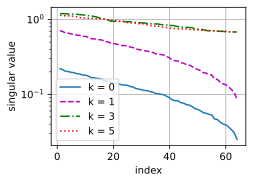

In [3]:
torch.manual_seed(0)
G = torch.randn(96, 64)
sigmas = [torch.linalg.svdvals(newton_schulz(G, num_iters=k))
          for k in (0, 1, 3, 5)]
d2l.plot(torch.arange(1, 65), sigmas, 'index', 'singular value',
         legend=[f'k = {k}' for k in (0, 1, 3, 5)], yscale='log')
print(f'singular values after 5 iterations: '
      f'[{sigmas[-1].min():.2f}, {sigmas[-1].max():.2f}]')

One iteration lifts the whole spectrum; three compress it to within a factor
of a few; after five, every singular value sits in a band around $1$, from
roughly $0.7$ to $1.2$. That is $\mathbf{U}\mathbf{V}^\top$ for an
optimizer's purposes, at the cost of fifteen matrix multiplications. (A
*nearly singular* direction takes a few more iterations to climb out, at
$3.4$-fold per pass; the exercises probe how much that matters in
training.)

## Muon from Scratch

### The Update

Muon assembles three ingredients we now have in hand. Gradients are noisy, so
we do not orthogonalize the raw gradient: we keep a momentum buffer, the
leaky average of that section, with the same $\mu = 0.95$ used by
its authors, and hand Newton--Schulz the Nesterov blend
$\mathbf{G}_t + \mu \mathbf{M}_t$ — the gradient plus a look ahead along the
freshly updated buffer. And the result is
rescaled once per matrix shape:

$$
\mathbf{M}_t = \mu\, \mathbf{M}_{t-1} + \mathbf{G}_t,
\qquad
\mathbf{W}_{t+1} = \mathbf{W}_t - \eta \cdot 0.2 \sqrt{\max(m, n)}\; \mathrm{NS}_5(\mathbf{G}_t + \mu\, \mathbf{M}_t)
$$

for an $m \times n$ matrix. The scale factor deserves a sentence, because it
is what makes Muon a drop-in teammate for AdamW. An orthogonalized matrix has
$\min(m, n)$ singular values equal to $1$, hence Frobenius norm
$\sqrt{\min(m, n)}$ and root-mean-square entry size $1 / \sqrt{\max(m, n)}$:
without correction, wide matrices would take smaller per-entry steps than
square ones. Multiplying by $0.2\sqrt{\max(m, n)}$ makes every matrix's
update have entrywise RMS $0.2\,\eta$ regardless of shape, which matches the
typical RMS of an AdamW update. With this convention, introduced for the
Moonlight model, a learning rate and weight decay tuned for AdamW transfer
directly to Muon [@Liu.Su.Yao.ea.2025], so the hybrid optimizer below
needs only one learning rate. (The original Muon used a different
shape factor, and the theoretically derived scale is
$\sqrt{\text{fan-out} / \text{fan-in}}$ per @Bernstein.2025; the
distinction matters when transferring across model widths, which is
that section's subject.)

The implementation is short. `reshape` handles the one wrinkle we will need
later: a convolution kernel is a matrix in disguise — one row per output
channel in PyTorch's OIHW layout, one column in Flax's HWIO, transposes of
each other, and orthogonalization commutes with transposition — so
flattening it lets the same code precondition CNNs. On our tiny
matrices the fifteen extra multiplications add a visible fraction to the
step time; at production scale, where the forward and backward passes
dwarf them, the reported overhead is around one percent of the training
FLOPs [@Jordan.Jin.Boza.ea.2024].

In [4]:
class Muon(torch.optim.Optimizer):
    """Steepest descent under the spectral norm: orthogonalized momentum."""
    def __init__(self, params, lr, momentum=0.95):
        super().__init__(params, dict(lr=lr, momentum=momentum))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                buf = self.state[p].setdefault('buf', torch.zeros_like(p))
                buf.mul_(group['momentum']).add_(p.grad)
                G = p.grad + group['momentum'] * buf  # Nesterov momentum
                M = G.reshape(len(G), -1)             # flattens conv kernels
                O = newton_schulz(M).reshape(p.shape)
                p.add_(O, alpha=-group['lr'] * 0.2 * math.sqrt(max(M.shape)))

### Dividing the Census

Muon is an optimizer for hidden matrices only, so a real training run is a
*hybrid*: the parameter-group machinery of that section, with the
census deciding who goes where. Hidden matrices go to Muon; embeddings, the
output head, and every one-dimensional tensor go to AdamW.

In [5]:
data = d2l.TimeMachine(batch_size=64, num_steps=64, tokenization='char',
                       num_train=100000)

def split_lm(model):
    hidden, rest = [], []
    for name, p in model.named_parameters():
        is_hidden = p.ndim == 2 and 'emb' not in name and 'head' not in name
        (hidden if is_hidden else rest).append(p)
    return hidden, rest

model = d2l.TinyLM(len(data.vocab))
hidden, rest = split_lm(model)
print(f'Muon:  {len(hidden):>2} tensors, '
      f'{sum(p.numel() for p in hidden):>7} parameters')
print(f'AdamW: {len(rest):>2} tensors, '
      f'{sum(p.numel() for p in rest):>7} parameters')

Muon:   8 tensors,  393216 parameters
AdamW: 22 tensors,   18972 parameters


The eight hidden matrices hold about 95% of the parameters. Note what the
split does to optimizer state: AdamW carries two buffers per parameter, Muon
one, so the hybrid's state memory is nearly half of all-AdamW's, an
accounting that section taught us to notice. The factory below builds
the hybrid; with the RMS-matched scale of the equation, both
halves share a single learning rate.

In [6]:
class MultiOptimizer:
    """Apply independent optimizers to disjoint parameter groups."""
    def __init__(self, *optimizers):
        self.optimizers = optimizers

    def step(self):
        for opt in self.optimizers:
            opt.step()

    def zero_grad(self):
        for opt in self.optimizers:
            opt.zero_grad()

def muon_adamw(hidden, rest, lr):
    return MultiOptimizer(Muon(hidden, lr=lr),
                          torch.optim.AdamW(rest, lr=lr, weight_decay=0.0))

### The Race on the Language Model

The protocol is the one from that section: same model, same
initialization, 2,000 steps at a constant learning rate, a four-point
learning-rate grid per contestant, best final training loss speaks for its
family. "Tuned" in what follows means the best of this coarse four-point
grid, nothing finer. Weight decay is switched off in both arms so that the
*only* difference between them is the direction of the update on the hidden
matrices. First the baseline, all parameters on AdamW:

In [7]:
def final_loss(losses, k=100):
    v = sum(losses[-k:]) / k
    return v if math.isfinite(v) else float('inf')

def smooth(losses, k=25):
    return [sum(losses[i:i + k]) / k
            for i in range(0, len(losses) - k + 1, k)]

def run_lm(make_optimizer, lrs, num_steps=2000):
    curves = {}
    for lr in lrs:
        torch.manual_seed(0)
        model = d2l.TinyLM(len(data.vocab))
        curves[lr] = d2l.train_lm(model, data, make_optimizer(model, lr),
                                  num_steps)
        print(f'lr {lr:g}: final loss {final_loss(curves[lr]):.3f}')
    return curves

adamw_lm = run_lm(
    lambda model, lr: torch.optim.AdamW(model.parameters(), lr,
                                        weight_decay=0.0),
    lrs=[3e-4, 1e-3, 3e-3, 1e-2])

lr 0.0003: final loss 1.506


lr 0.001: final loss 1.157


lr 0.003: final loss 0.913


lr 0.01: final loss 0.972


Now the hybrid, over the same grid; thanks to the RMS matching, the grid
means the same thing for both:

In [8]:
muon_lm = run_lm(
    lambda model, lr: muon_adamw(*split_lm(model), lr),
    lrs=[3e-4, 1e-3, 3e-3, 1e-2])

lr 0.0003: final loss 1.519


lr 0.001: final loss 1.074


lr 0.003: final loss 0.928


lr 0.01: final loss 0.833


final perplexity: AdamW 2.49, Muon+AdamW 2.30


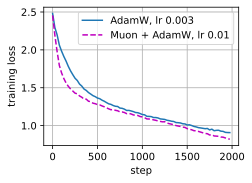

In [9]:
best_adamw = min(adamw_lm, key=lambda lr: final_loss(adamw_lm[lr]))
best_muon = min(muon_lm, key=lambda lr: final_loss(muon_lm[lr]))
d2l.plot(list(range(0, 2000, 25)),
         [smooth(adamw_lm[best_adamw]), smooth(muon_lm[best_muon])],
         'step', 'training loss',
         legend=[f'AdamW, lr {best_adamw:g}',
                 f'Muon + AdamW, lr {best_muon:g}'])
print(f'final perplexity: '
      f'AdamW {math.exp(final_loss(adamw_lm[best_adamw])):.2f}, '
      f'Muon+AdamW {math.exp(final_loss(muon_lm[best_muon])):.2f}')

Tuned against tuned, the hybrid finishes a few percent of perplexity below
AdamW; from a single seed we claim a modest edge and no more. The edge is
not nothing — the
hybrid gets there carrying nearly half the optimizer state — but a
0.4M-parameter model trained for a minute cannot show much more. The
fair-tuning literature discussed at the end of this section measures
Muon-family gains in tens of percent of data efficiency at small scale,
an effect two thousand steps can only hint at. The demo is mechanism, not
benchmark; before drawing conclusions, look at the same race in the JAX tab,
where the identical protocol produces a very different margin.

### The Same Race on a CNN

that section found that Adam's advantage over SGD, dramatic on the
language model, nearly vanished on a CNN. It is natural to ask the same
question of Muon. We reuse the compact Fashion-MNIST CNN from that section,
along with its test-accuracy check; `reshape` in the update flattens each
convolution kernel to a matrix (one row per output channel in PyTorch, one
column in Flax), and the output head stays with AdamW.

In [10]:
fashion = d2l.FashionMNIST(batch_size=256)

def make_cnn():
    return nn.Sequential(
        nn.LazyConv2d(32, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),
        nn.LazyConv2d(64, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(), nn.LazyLinear(128), nn.ReLU(), nn.LazyLinear(10))

def split_cnn(model):
    head = model[-1].weight
    hidden = [p for p in model.parameters()
              if p.ndim >= 2 and p is not head]
    rest = [p for p in model.parameters() if p.ndim < 2 or p is head]
    return hidden, rest

def test_accuracy(model, data):
    device = d2l.try_gpu()
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X, y in data.val_dataloader():
            X, y = X.to(device), y.to(device)
            correct += float((model(X).argmax(axis=1) == y).sum())
            total += y.numel()
    return correct / total

def run_cnn(make_optimizer, lrs, num_steps=2000):
    curves, accs = {}, {}
    for lr in lrs:
        torch.manual_seed(0)
        model = make_cnn()
        model(next(iter(fashion.train_dataloader()))[0])
        curves[lr] = d2l.train_lm(model, fashion, make_optimizer(model, lr),
                                  num_steps)
        accs[lr] = test_accuracy(model, fashion)
        print(f'lr {lr:g}: final loss {final_loss(curves[lr]):.3f}, '
              f'test accuracy {accs[lr]:.3f}')
    return curves, accs

adamw_cnn, adamw_acc = run_cnn(
    lambda model, lr: torch.optim.AdamW(model.parameters(), lr,
                                        weight_decay=0.0),
    lrs=[3e-4, 1e-3, 3e-3, 1e-2])

lr 0.0003: final loss 0.284, test accuracy 0.889


lr 0.001: final loss 0.192, test accuracy 0.915


lr 0.003: final loss 0.110, test accuracy 0.916


lr 0.01: final loss 0.169, test accuracy 0.897


In [11]:
muon_cnn, muon_acc = run_cnn(
    lambda model, lr: muon_adamw(*split_cnn(model), lr),
    lrs=[3e-4, 1e-3, 3e-3, 1e-2])

lr 0.0003: final loss 0.164, test accuracy 0.912


lr 0.001: final loss 0.031, test accuracy 0.921


lr 0.003: final loss 0.025, test accuracy 0.914


lr 0.01: final loss 0.102, test accuracy 0.903


test accuracy: AdamW 0.916, Muon+AdamW 0.914


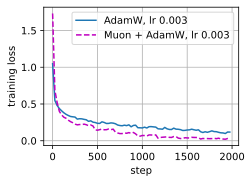

In [12]:
best_adamw_cnn = min(adamw_cnn, key=lambda lr: final_loss(adamw_cnn[lr]))
best_muon_cnn = min(muon_cnn, key=lambda lr: final_loss(muon_cnn[lr]))
d2l.plot(list(range(0, 2000, 25)),
         [smooth(adamw_cnn[best_adamw_cnn]), smooth(muon_cnn[best_muon_cnn])],
         'step', 'training loss',
         legend=[f'AdamW, lr {best_adamw_cnn:g}',
                 f'Muon + AdamW, lr {best_muon_cnn:g}'])
print(f'test accuracy: AdamW {adamw_acc[best_adamw_cnn]:.3f}, '
      f'Muon+AdamW {muon_acc[best_muon_cnn]:.3f}')

The result rewards reading both scoreboards. On training loss the hybrid
pulls clearly ahead: orthogonalized updates drive this small CNN into its
memorization regime several times faster. On test accuracy, the number a
vision practitioner actually cares about, the two land within about a point
of each other. Optimizing faster and predicting better are different claims,
and on a small, quickly saturated task the second is the one that resists
improvement — the same compression of differences that that section
found between Adam and SGD here. The general lesson survives translation:
an optimizer comparison is a statement about a workload and a metric, not a
universal ranking.

### Library Implementations

PyTorch ships Muon in core since version 2.9. Mirroring our scratch version,
`torch.optim.Muon` accepts only the 2-D hidden matrices (its documentation
directs embeddings, biases, and heads to AdamW), applies Nesterov-style
momentum before orthogonalizing, and offers the RMS-matched scale of
the equation as `adjust_lr_fn='match_rms_adamw'`. Its default
weight decay is 0.1, not zero, so we switch it off to match the protocol
above.

In [13]:
torch.manual_seed(0)
model = d2l.TinyLM(len(data.vocab))
hidden, rest = split_lm(model)
optimizer = MultiOptimizer(
    torch.optim.Muon(hidden, lr=best_muon, momentum=0.95, nesterov=True,
                     weight_decay=0.0, adjust_lr_fn='match_rms_adamw'),
    torch.optim.AdamW(rest, lr=best_muon, weight_decay=0.0))
losses = d2l.train_lm(model, data, optimizer, 2000)
print(f'final loss {final_loss(losses):.3f}')

final loss 0.832


## The Preconditioning Family

Muon looks exotic until it is placed on the family tree, where it turns out
to be the frugal child of a long line. Every branch answers the question
posed in that section: gradient descent assumes round level sets, real
losses have curved ones, and some matrix should reshape the gradient
accordingly. Adam estimates a *diagonal* such matrix from gradient history.
The methods below estimate structure per layer, exploiting the same fact
Muon does: parameters come in matrices.

K-FAC [@Martens.Grosse.2015] is the family's ancestor. It approximates
each layer's block of the Fisher information matrix, curvature measured
between the *distributions* the model defines, as a Kronecker product of two
small matrices, the second moments of the layer's inputs and of its output
gradients. Preconditioning by a Kronecker product costs two small inverses
rather than one enormous one, which made second-order-style updates feasible
for neural networks and connected them to the natural gradient of
@Amari.1998 .

Shampoo [@Gupta.Koren.Singer.2018] keeps the two-sided structure but
builds the factors the AdaGrad way, from accumulated gradient statistics,
preconditioning each gradient matrix as $\mathbf{L}_t^{-1/4} \mathbf{G}_t
\mathbf{R}_t^{-1/4}$ with $\mathbf{L}_t = \sum_s \mathbf{G}_s
\mathbf{G}_s^\top$ and $\mathbf{R}_t = \sum_s \mathbf{G}_s^\top
\mathbf{G}_s$. A distributed implementation of Shampoo won the
external-tuning track of the AlgoPerf benchmark, finishing its workloads
about 30% faster than the tuned AdamW baseline
[@Dahl.Schneider.Nado.ea.2023; @Kasimbeg.Schneider.Eschenhagen.ea.2025] —
the strongest protocol-controlled evidence that matrix preconditioning pays.
SOAP [@Vyas.Morwani.Zhao.ea.2024] refines it further by running Adam
inside Shampoo's slowly refreshed eigenbasis, cutting the overhead between
factor recomputations.

Muon's place in the tree is now easy to state: *it is Shampoo with the
memory removed*. Switch off Shampoo's accumulators, keeping only the current
gradient with SVD $\mathbf{G} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$,
and

$$
(\mathbf{G}\mathbf{G}^\top)^{-1/4}\, \mathbf{G}\, (\mathbf{G}^\top\mathbf{G})^{-1/4} = \mathbf{U}\boldsymbol{\Sigma}^{-1/2}\mathbf{U}^\top \cdot \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top \cdot \mathbf{V}\boldsymbol{\Sigma}^{-1/2}\mathbf{V}^\top = \mathbf{U}\mathbf{V}^\top,
$$

the orthogonalized gradient again [@Bernstein.Newhouse.2024]. What Muon
discards is the preconditioner state and the factor inverses; what it keeps
is the geometry. On the other side of the tree, the same anatomy identifies
Lion [@Chen.Liang.Huang.ea.2023], an update found by symbolic program
search, as the lean member of the *sign* branch: one momentum buffer and a
sign, steepest descent under $\ell_\infty$ with even less state than Adam.
You will implement it in the exercises in about six lines. The full ladder,
from diagonal through Kronecker to spectral, with the derivations, is
assembled in that section.

## Muon in the Wild

Muon's rise was unusually public. It debuted in late 2024 not in a paper but
as a record on the NanoGPT speedrun [@Jordan.2024], a standing
competition to train a fixed GPT-2-class model to a fixed validation loss on
fixed hardware in the least wall-clock time. The speedrun is a small model of
good evidence culture: one variable changes per record, the diff is public,
and anyone can rerun it. Its headline number, a baseline of 45 minutes
driven down to a few minutes in under two years, mixes optimizer,
architecture, and data-schedule improvements and should not be read as an
optimizer benchmark; but individual records isolate single changes, and
Muon's debut cut the then-record by roughly a third.

Production adoption followed within months. Moonshot's Moonlight report
demonstrated Muon at multi-billion-parameter scale, introduced the
RMS-matching convention of the equation, and reported matched
losses for roughly half the training compute of its AdamW baseline
[@Liu.Su.Yao.ea.2025]. Kimi K2, a trillion-parameter
mixture-of-experts model, was pretrained on 15.5 trillion tokens with
MuonClip, Muon plus a cap on attention logits (QK-clip) to contain the
instability that surfaced at that scale, and reports zero loss spikes for
the entire run [@Kimi.Team.2025]. GLM-4.5 likewise trained with Muon
[@Zeng.Lv.Zheng.ea.2025]. An optimizer in the training runs of multiple frontier
labs, and in core PyTorch, within two years of its first appearance is a
pace the field had not seen since Adam itself.

Against this, hold the sobering result of the fair-tuning literature.
@Wen.Hall.Ma.ea.2025 re-benchmarked eleven optimizers under matched,
per-optimizer hyperparameter tuning across model scales, and found that most
published "beats AdamW by 2×" claims deflate badly: the genuine speedups
belong to the matrix-preconditioned family (Muon, SOAP, Kron), but they are
roughly 1.4× at 100M parameters and shrink toward 1.1× by a billion. The
study's most instructive case is Sophia [@Liu.Li.Hall.ea.2023], a
second-order method that reported a 2× speedup on GPT-2 pretraining and did
not replicate under matched tuning — a finding published by a group
overlapping with Sophia's own authors, which is how self-correction is
supposed to work. None of this contradicts the production story; it bounds
it. Benchmark verdicts are also protocol-dependent: AlgoPerf's fixed tuning
budgets crowned Shampoo, the speedrun's unlimited tinkering crowned Muon,
and a comparison run at one scale with one tuning budget is evidence about
that protocol, not a universal ranking
[@Schmidt.Schneider.Hennig.2021]. Where this leaves a practitioner
in 2026: AdamW remains the default; Muon on hidden matrices is the one
challenger with both a clean derivation and frontier-scale production
mileage, and its advantage is real but measured in tens of percent, not
multiples.

## Summary

Steepest descent is not one algorithm but a family indexed by a norm: the
Euclidean ball yields normalized SGD, the $\ell_\infty$ box yields sign
descent and its
smoothed form Adam, and the spectral ball, the right measure for a matrix
that transforms activations, yields the orthogonalized gradient
$\mathbf{U}\mathbf{V}^\top$. Muon computes it without an SVD by a tuned
five-step Newton--Schulz iteration, pure matrix multiplications that run in
low precision, applies it to each hidden matrix's Nesterov blend
$\mathbf{G}_t + \mu\,\mathbf{M}_t$ of gradient and momentum buffer, and
rescales by $0.2\sqrt{\max(m, n)}$ so one learning rate serves both Muon and
the AdamW that handles embeddings, heads, and vectors. It is Shampoo without
accumulators, K-FAC's grandchild, and the spectral rung of the
preconditioning ladder.

On our tiny testbed the hybrid beat tuned AdamW in both
single-seed runs while carrying nearly half the optimizer state, with a
margin that ranged from modest (PyTorch) to substantial (JAX) under the
identical protocol; on the CNN it optimized faster but generalized the
same. All of this is
consistent with the production record: real gains of tens of percent on
transformer pretraining at matched tuning, trillion-parameter runs without
loss spikes, and no revolution. The methodological lesson is worth as much
as the method: optimizer claims deserve matched tuning, stated protocols,
and suspicion of round numbers.

## Exercises

1. Derive the sign-descent limit of Adam. Setting $\beta_1 = \beta_2 = 0$ in
   the equation and the equation, show that the
   update becomes $\eta\, \mathbf{g}_t / (|\mathbf{g}_t| + \epsilon)$ and
   hence $\eta\, \mathrm{sign}(\mathbf{g}_t)$ as $\epsilon \to 0$. Which
   norm ball in the equation does this step solve? What do the two
   moving averages restore that the limit lacks?
1. Verify the RMS-matching factor. Show that $\|\mathbf{U}\mathbf{V}^\top\|_F
   = \sqrt{\min(m, n)}$ for an $m \times n$ matrix of rank $\min(m, n)$, so
   the orthogonalized update has entrywise RMS $1/\sqrt{\max(m, n)}$. Then
   instrument a short AdamW run of `TinyLM` to measure the actual RMS of its
   updates, and compare with the constant $0.2$ used in
   the equation.
1. Rerun the tuned hybrid with `num_iters=1` and `num_iters=10` in
   `newton_schulz`. Measure final loss and wall-clock time per step. Where
   does the quality saturate, and why does one iteration already capture
   part of the benefit? (Plot the quintic $p(x)$ of the equation
   to see what a single application does to the spectrum.)
1. Move the embedding tables and the output head into the Muon group and
   rerun the sweep. Explain what you observe using the one-hot-input
   argument: what does orthogonalizing an embedding table's momentum do to
   the update received by the rows of rare tokens?
1. Implement Lion [@Chen.Liang.Huang.ea.2023] in about six lines: with
   buffer $\mathbf{m}_t$, update $\mathbf{x}_{t+1} = \mathbf{x}_t - \eta\,
   \mathrm{sign}(\beta_1 \mathbf{m}_{t-1} + (1 - \beta_1)\, \mathbf{g}_t)$
   followed by $\mathbf{m}_t = \beta_2 \mathbf{m}_{t-1} + (1 - \beta_2)\,
   \mathbf{g}_t$, with $(\beta_1, \beta_2) = (0.9, 0.99)$. Race it against
   AdamW and the hybrid on `TinyLM` at matched four-point tuning (Lion's
   best learning rate is typically several times smaller than AdamW's).
   How much optimizer state does each method carry per parameter?
1. Complete the proof of the equation: show that if
   $\|\mathbf{A}\|_2 \leq 1$ then every diagonal entry of
   $\mathbf{U}^\top \mathbf{A} \mathbf{V}$ has absolute value at most $1$,
   and identify when equality holds simultaneously for all entries.